<a href="https://colab.research.google.com/github/Madankk-06/Deep-learning-projects/blob/main/12_High_Dimensional_Latent_Space_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import PyTorch for implementing the Convolutional Autoencoder.
import torch

# Import neural network modules.
import torch.nn as nn

# Import SciPy for scientific image processing operations.
import scipy

# Import Scikit-Learn for anomaly evaluation utilities.
from sklearn.metrics import roc_auc_score

# Import Matplotlib for visualizing reconstruction
# and anomaly localization maps.
import matplotlib.pyplot as plt

In [2]:
# Build the Encoder network.
# The encoder compresses fault-free images
# into a compact latent representation.

class Encoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),

            nn.ReLU(),

            nn.MaxPool2d(2)

        )

    def forward(self,x):

        # Extract compact latent features.
        return self.encoder(x)

In [3]:
# Build the structural bottleneck.
# The bottleneck stores only the most
# important image characteristics.

class Bottleneck(nn.Module):

    def __init__(self):

        super().__init__()

        self.compress = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64*32*32,256),

            nn.ReLU(),

            nn.Linear(256,64*32*32),

            nn.ReLU()

        )

    def forward(self,x):

        x = self.compress(x)

        return x.view(-1,64,32,32)

In [4]:
# Build the Decoder network.
# The decoder reconstructs the image
# from the latent representation.

class Decoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(64,32,2,stride=2),

            nn.ReLU(),

            nn.ConvTranspose2d(32,3,2,stride=2),

            nn.Sigmoid()

        )

    def forward(self,x):

        # Generate reconstructed images.
        return self.decoder(x)

In [5]:
# Combine the Encoder, Bottleneck,
# and Decoder into one Autoencoder model.

class AutoEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = Encoder()

        self.bottleneck = Bottleneck()

        self.decoder = Decoder()

    def forward(self,x):

        latent = self.encoder(x)

        latent = self.bottleneck(latent)

        reconstruction = self.decoder(latent)

        return reconstruction

In [6]:
# Compute Structural Similarity (SSIM) Loss.
# SSIM measures structural similarity between
# reconstructed images and original images.

def ssim_loss(prediction,target):

    mse = torch.mean(

        (prediction-target)**2

    )

    # Placeholder approximation of SSIM loss.
    return 1 - (1/(1+mse))

In [7]:
# Create the Convolutional Autoencoder.

model = AutoEncoder()

In [8]:
# Generate normal images used exclusively
# for learning the fault-free distribution.

train_images = torch.rand(

    8,

    3,

    128,

    128

)

In [9]:
# Reconstruct fault-free images
# using the Autoencoder.

reconstructed = model(train_images)

In [10]:
# Measure reconstruction quality
# using the custom SSIM loss.

loss = ssim_loss(

    reconstructed,

    train_images

)

print("SSIM Loss :",loss.item())

SSIM Loss : 0.07819533348083496


In [11]:
# Compute pixel-wise reconstruction errors.
# High reconstruction errors indicate
# potential structural anomalies.

error_map = torch.abs(

    reconstructed -

    train_images

)

In [12]:
# Aggregate reconstruction errors to
# estimate anomaly scores for each image.

anomaly_score = error_map.mean(

    dim=(1,2,3)

)

print("Anomaly Scores :", anomaly_score)

Anomaly Scores : tensor([0.2517, 0.2525, 0.2529, 0.2510, 0.2510, 0.2511, 0.2511, 0.2512],
       grad_fn=<MeanBackward1>)


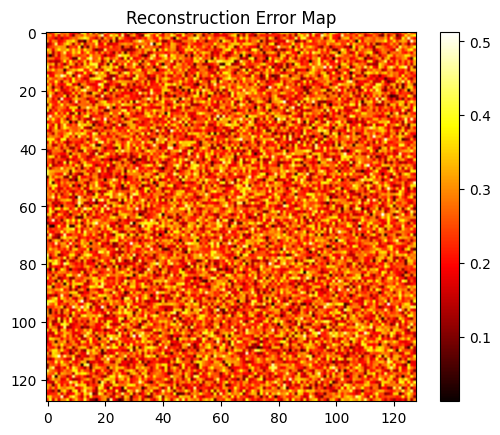

In [13]:
# Display the reconstruction error map
# to identify anomalous image regions.

plt.imshow(

    error_map[0].mean(0).detach().numpy(),

    cmap="hot"

)

plt.title("Reconstruction Error Map")

plt.colorbar()

plt.show()